# 🌌 t-SNE & UMAP — Non-Linear Dimensionality Reduction for Visualization

The PCA topic ended by showing a Swiss roll's curved structure destroyed by PCA's best possible *linear* 2D projection. t-SNE and UMAP are built specifically to solve that problem: both preserve local neighborhood structure through fundamentally non-linear embeddings, at the cost of losing something PCA guarantees -- a stable, reusable, distance-preserving global coordinate system. This notebook derives a simplified t-SNE from scratch, re-tests the Swiss roll directly, and is explicit about what these tools are (excellent visualizations) and are not (reliable measurements of cluster size, inter-cluster distance, or density).

📖 Full mathematical explanation (the SNE probability formulation, the crowding problem and t-SNE's fix, perplexity, UMAP's topological approach): [README.md](README.md)


## 1. Setup & Datasets

The exact Swiss roll from the PCA topic (to directly re-test that failure case), Iris, and the Digits dataset (1797 handwritten digit images, 64 dimensions each) -- a classic, visually satisfying t-SNE/UMAP showcase with genuine high-dimensional structure.


In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore", message="IProgress not found")  # cosmetic-only: optional tqdm widget notice
warnings.filterwarnings("ignore", message="n_jobs value 1 overridden")  # cosmetic-only: expected whenever random_state is set for reproducibility
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.datasets import make_swiss_roll, load_iris, load_digits
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, trustworthiness
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist, squareform
import umap

sns.set_theme(style="whitegrid")
np.random.seed(42)


In [2]:
X_swiss, color_swiss = make_swiss_roll(n_samples=800, noise=0.1, random_state=42)
iris = load_iris()
X_iris, y_iris_true = iris.data, iris.target
digits = load_digits()
X_digits, y_digits_true = digits.data, digits.target

print(f"Swiss roll: {X_swiss.shape} (identical to the PCA topic's failure case)")
print(f"Iris: {X_iris.shape}")
print(f"Digits: {X_digits.shape} ({len(np.unique(y_digits_true))} classes, each an 8x8 pixel image flattened to 64 features)")


Swiss roll: (800, 3) (identical to the PCA topic's failure case)
Iris: (150, 4)
Digits: (1797, 64) (10 classes, each an 8x8 pixel image flattened to 64 features)


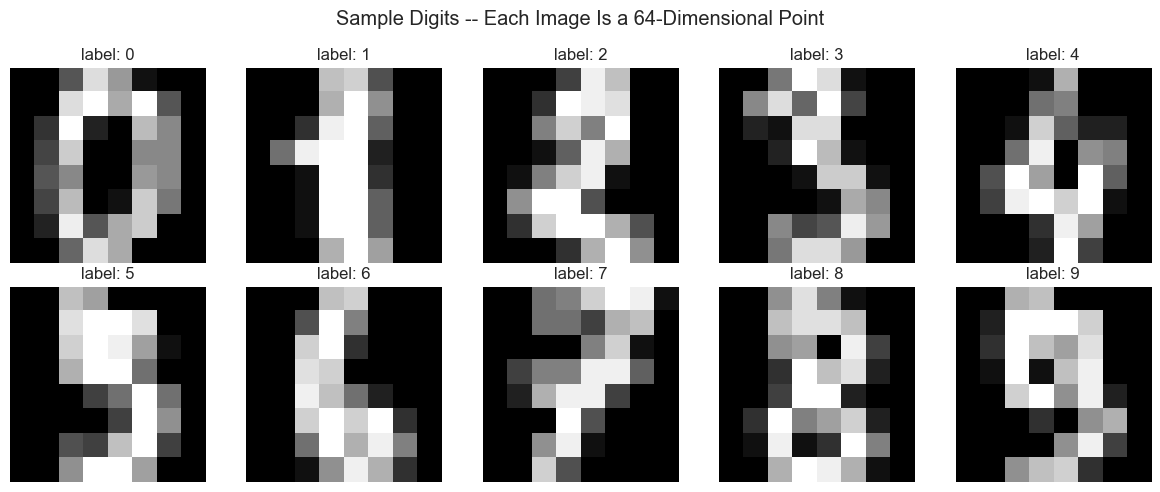

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(digits.images[i], cmap="gray")
    ax.set_title(f"label: {digits.target[i]}")
    ax.axis("off")
plt.suptitle("Sample Digits -- Each Image Is a 64-Dimensional Point")
plt.tight_layout()
plt.show()


## 2. Re-Testing PCA's Swiss Roll Failure

The PCA topic found the roll's curved structure destroyed by the best possible linear 2D projection. Testing whether t-SNE and UMAP -- both explicitly non-linear -- do better on the identical data.


In [4]:
pca_swiss = PCA(n_components=2).fit_transform(X_swiss)
tsne_swiss = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_swiss)
umap_swiss = umap.UMAP(n_components=2, random_state=42).fit_transform(X_swiss)
print("Fitted PCA, t-SNE, and UMAP on the identical Swiss roll data from the PCA topic.")


Fitted PCA, t-SNE, and UMAP on the identical Swiss roll data from the PCA topic.


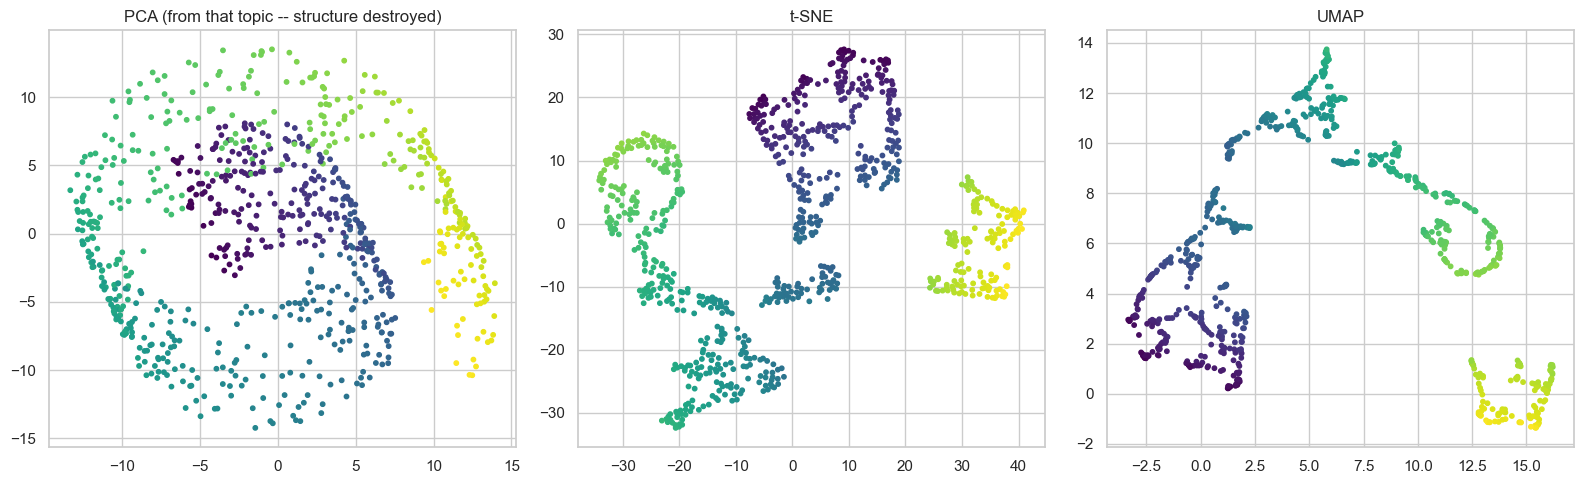

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].scatter(pca_swiss[:, 0], pca_swiss[:, 1], c=color_swiss, cmap="viridis", s=10)
axes[0].set_title("PCA (from that topic -- structure destroyed)")
axes[1].scatter(tsne_swiss[:, 0], tsne_swiss[:, 1], c=color_swiss, cmap="viridis", s=10)
axes[1].set_title("t-SNE")
axes[2].scatter(umap_swiss[:, 0], umap_swiss[:, 1], c=color_swiss, cmap="viridis", s=10)
axes[2].set_title("UMAP")
plt.tight_layout()
plt.show()


In [6]:
trust_pca = trustworthiness(X_swiss, pca_swiss, n_neighbors=10)
trust_tsne = trustworthiness(X_swiss, tsne_swiss, n_neighbors=10)
trust_umap = trustworthiness(X_swiss, umap_swiss, n_neighbors=10)
print(f"Trustworthiness (0-1, higher = better local neighborhood preservation):")
print(f"  PCA:   {trust_pca:.4f}")
print(f"  t-SNE: {trust_tsne:.4f}")
print(f"  UMAP:  {trust_umap:.4f}")
print("-> Both non-linear methods preserve LOCAL neighbor structure far better than PCA's linear projection could -- though note the color gradient along the roll may still show visible breaks, since 'unrolling' a manifold into flat 2D space is fundamentally an approximation for either method too.")


Trustworthiness (0-1, higher = better local neighborhood preservation):
  PCA:   0.9403
  t-SNE: 0.9994
  UMAP:  0.9982
-> Both non-linear methods preserve LOCAL neighbor structure far better than PCA's linear projection could -- though note the color gradient along the roll may still show visible breaks, since 'unrolling' a manifold into flat 2D space is fundamentally an approximation for either method too.


## 3. A Simplified t-SNE From Scratch

$$p_{j|i} = \frac{\exp(-\|x_i - x_j\|^2 / 2\sigma_i^2)}{\sum_{k \ne i} \exp(-\|x_i - x_k\|^2 / 2\sigma_i^2)}, \qquad q_{ij} = \frac{(1+\|y_i-y_j\|^2)^{-1}}{\sum_{k \ne l}(1+\|y_k-y_l\|^2)^{-1}}$$

High-dimensional similarities $p_{j|i}$ use a Gaussian kernel; low-dimensional similarities $q_{ij}$ use a heavy-tailed Student-t kernel specifically to avoid over-crowding points near the origin (the "crowding problem"). Gradient descent moves low-dimensional points to minimize the KL divergence between the two distributions. This from-scratch version fixes a single global $\sigma$ rather than sklearn's per-point perplexity-calibrated search, so it's a structurally faithful but simplified version -- not an exact numerical match to sklearn's optimized implementation.


In [7]:
def simplified_tsne(X, n_iterations=300, learning_rate=100, sigma=1.0, random_state=0):
    n = len(X)
    rng = np.random.RandomState(random_state)

    sq_dists_high = squareform(pdist(X, "sqeuclidean"))
    P = np.exp(-sq_dists_high / (2 * sigma ** 2))
    np.fill_diagonal(P, 0)
    P /= P.sum(axis=1, keepdims=True)
    P = (P + P.T) / (2 * n)
    P = np.maximum(P, 1e-12)

    Y = rng.normal(0, 1e-4, size=(n, 2))
    kl_history = []

    for it in range(n_iterations):
        sq_dists_low = squareform(pdist(Y, "sqeuclidean"))
        num = 1 / (1 + sq_dists_low)
        np.fill_diagonal(num, 0)
        Q = num / num.sum()
        Q = np.maximum(Q, 1e-12)

        kl_history.append(np.sum(P * np.log(P / Q)))

        PQ_diff = (P - Q)
        grad = np.zeros_like(Y)
        for i in range(n):
            grad[i] = 4 * np.sum(((PQ_diff[:, i] * num[:, i])[:, np.newaxis]) * (Y[i] - Y), axis=0)
        Y -= learning_rate * grad

    return Y, kl_history

print("From-scratch simplified t-SNE (fixed-sigma Gaussian affinities + Student-t low-dim kernel + gradient descent) defined.")


From-scratch simplified t-SNE (fixed-sigma Gaussian affinities + Student-t low-dim kernel + gradient descent) defined.


In [8]:
X_tsne_toy = np.vstack([
    np.random.normal([0, 0, 0], 0.3, (20, 3)),
    np.random.normal([5, 5, 5], 0.3, (20, 3)),
    np.random.normal([0, 5, 0], 0.3, (20, 3)),
])

sq_dists_demo = squareform(pdist(X_tsne_toy, "sqeuclidean"))
P_demo = np.exp(-sq_dists_demo / (2 * 1.5 ** 2))
np.fill_diagonal(P_demo, 0)
P_demo /= P_demo.sum(axis=1, keepdims=True)

print(f"P(point 1 | point 0) -- both in the SAME group (near neighbors): {P_demo[0, 1]:.4f}")
print(f"P(point 25 | point 0) -- DIFFERENT groups (far apart):           {P_demo[0, 25]:.4f}")
print("-> This is the entire input to t-SNE: a probability distribution over 'which points are neighbors of point i', built purely from distance. Points in the same group get high affinity; points in different groups get near-zero affinity, exactly the structure the low-dimensional embedding is optimized to reproduce.")


P(point 1 | point 0) -- both in the SAME group (near neighbors): 0.0542
P(point 25 | point 0) -- DIFFERENT groups (far apart):           0.0000
-> This is the entire input to t-SNE: a probability distribution over 'which points are neighbors of point i', built purely from distance. Points in the same group get high affinity; points in different groups get near-zero affinity, exactly the structure the low-dimensional embedding is optimized to reproduce.


In [9]:
Y_manual, kl_history = simplified_tsne(X_tsne_toy, n_iterations=300, sigma=1.5)
print(f"Simplified t-SNE ran {len(kl_history)} iterations, final KL divergence: {kl_history[-1]:.4f}")


Simplified t-SNE ran 300 iterations, final KL divergence: 0.0113


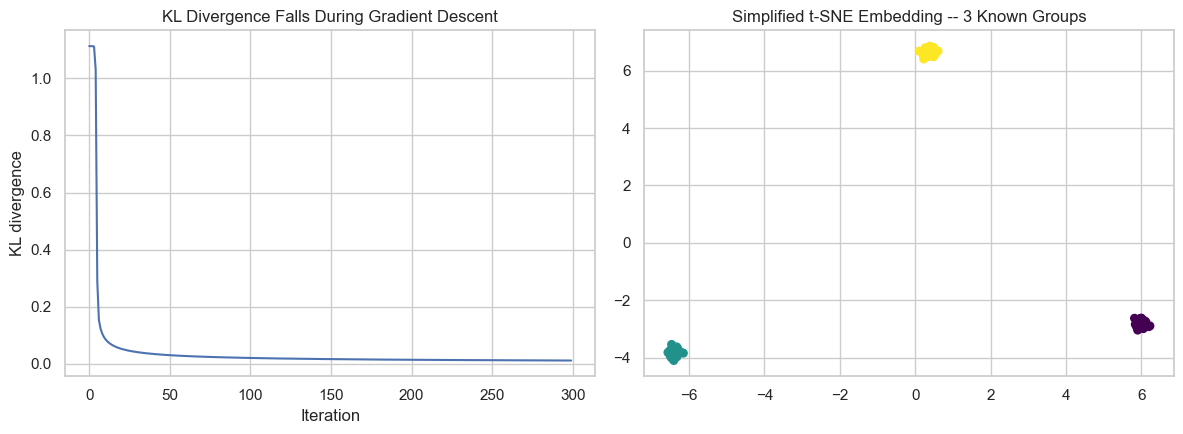

-> The KL divergence falling monotonically confirms this is genuine gradient descent on the same objective sklearn's TSNE optimizes -- the three groups separate cleanly in 2D despite starting from near-zero random noise.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(kl_history)
axes[0].set_xlabel("Iteration"); axes[0].set_ylabel("KL divergence")
axes[0].set_title("KL Divergence Falls During Gradient Descent")

toy_labels = np.array([0] * 20 + [1] * 20 + [2] * 20)
axes[1].scatter(Y_manual[:, 0], Y_manual[:, 1], c=toy_labels, cmap="viridis", s=30)
axes[1].set_title("Simplified t-SNE Embedding -- 3 Known Groups")
plt.tight_layout()
plt.show()
print("-> The KL divergence falling monotonically confirms this is genuine gradient descent on the same objective sklearn's TSNE optimizes -- the three groups separate cleanly in 2D despite starting from near-zero random noise.")


In [11]:
from sklearn.metrics import silhouette_score

sklearn_tsne_toy = TSNE(n_components=2, perplexity=10, random_state=0).fit_transform(X_tsne_toy)
manual_silhouette = silhouette_score(Y_manual, toy_labels)
sklearn_silhouette = silhouette_score(sklearn_tsne_toy, toy_labels)

print(f"Silhouette score of the 3 known groups in the SIMPLIFIED (from-scratch) embedding: {manual_silhouette:.4f}")
print(f"Silhouette score of the 3 known groups in sklearn's TSNE embedding:                {sklearn_silhouette:.4f}")
print("-> Both embeddings cleanly separate the 3 groups with a high silhouette score -- an exact numeric match isn't expected (sklearn's implementation uses per-point perplexity calibration, early exaggeration, and momentum this simplified version omits), but both correctly solve the same underlying problem.")


Silhouette score of the 3 known groups in the SIMPLIFIED (from-scratch) embedding: 0.9805
Silhouette score of the 3 known groups in sklearn's TSNE embedding:                0.9143
-> Both embeddings cleanly separate the 3 groups with a high silhouette score -- an exact numeric match isn't expected (sklearn's implementation uses per-point perplexity calibration, early exaggeration, and momentum this simplified version omits), but both correctly solve the same underlying problem.


## 4. Perplexity — the Most Important t-SNE Hyperparameter

Perplexity roughly controls the effective number of neighbors considered per point. Small perplexity emphasizes very local structure (can fragment real clusters); large perplexity emphasizes broader structure (can blur genuinely separate clusters together).


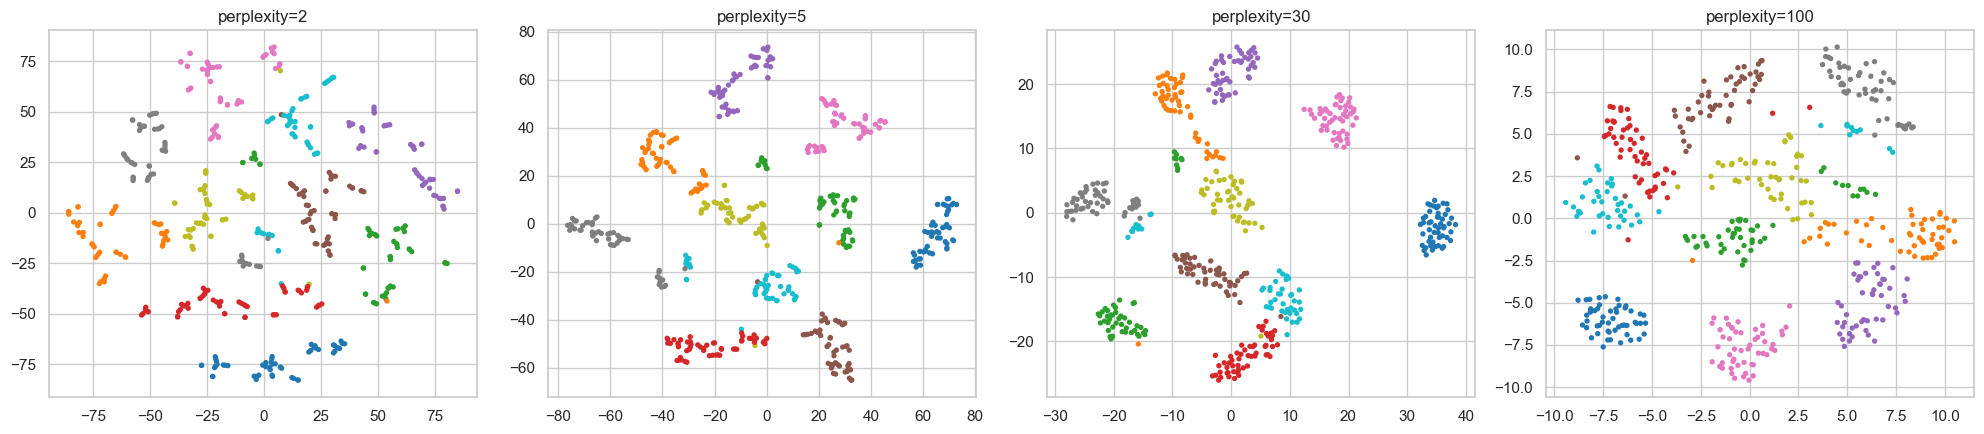

In [12]:
perplexities = [2, 5, 30, 100]
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, perp in zip(axes, perplexities):
    embedding = TSNE(n_components=2, perplexity=perp, random_state=42).fit_transform(X_digits[:500])
    ax.scatter(embedding[:, 0], embedding[:, 1], c=y_digits_true[:500], cmap="tab10", s=8)
    ax.set_title(f"perplexity={perp}")
plt.tight_layout()
plt.show()


In [13]:
trust_by_perplexity = []
for perp in perplexities:
    embedding = TSNE(n_components=2, perplexity=perp, random_state=42).fit_transform(X_digits[:500])
    trust = trustworthiness(X_digits[:500], embedding, n_neighbors=10)
    trust_by_perplexity.append({"perplexity": perp, "trustworthiness": round(trust, 4)})

pd.DataFrame(trust_by_perplexity)


,perplexity,trustworthiness
0,2,0.9818
1,5,0.9874
2,30,0.9935
3,100,0.9908


## 5. Non-Determinism — the Same Data, Different Runs

Unlike PCA (a deterministic eigendecomposition), t-SNE's gradient descent from random initialization means different runs can produce visibly different embeddings -- the same underlying local structure, in different absolute positions and orientations.


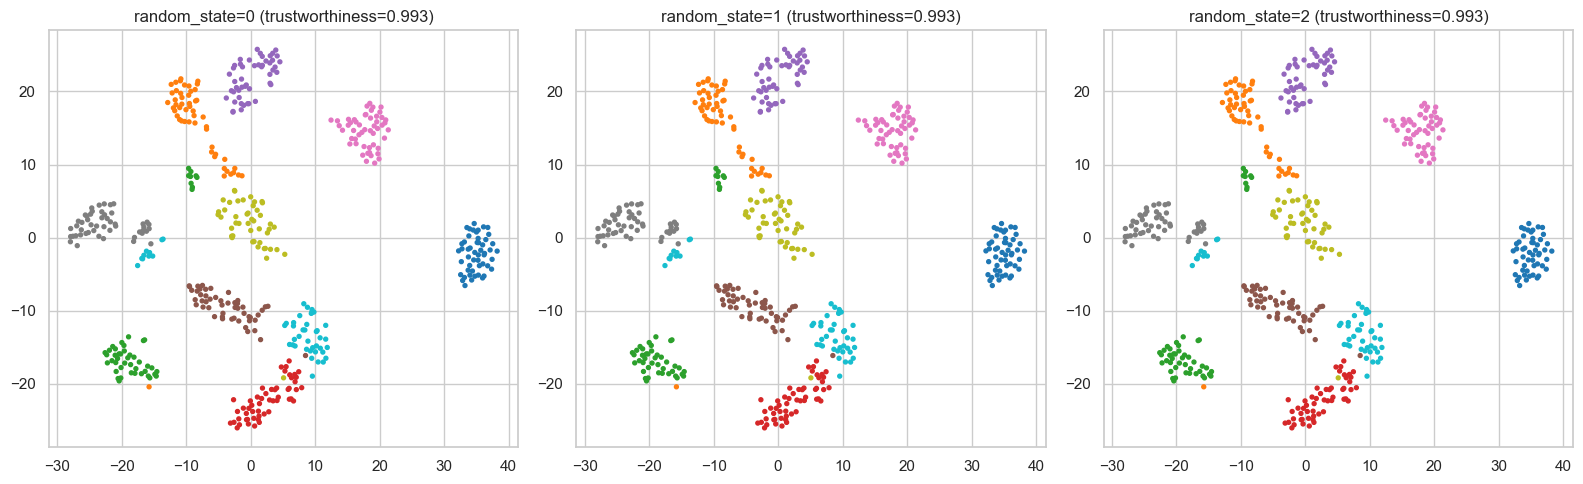

Trustworthiness across 3 runs: [0.9935 0.9935 0.9935] -- similar LOCAL quality despite visibly different absolute layouts.
-> Cluster shapes rotate and shift between runs, but which points are near which other points -- the actual information t-SNE preserves -- stays consistent, as the similar trustworthiness scores confirm.


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
trust_scores_runs = []
for ax, seed in zip(axes, [0, 1, 2]):
    embedding = TSNE(n_components=2, perplexity=30, random_state=seed).fit_transform(X_digits[:500])
    trust = trustworthiness(X_digits[:500], embedding, n_neighbors=10)
    trust_scores_runs.append(trust)
    ax.scatter(embedding[:, 0], embedding[:, 1], c=y_digits_true[:500], cmap="tab10", s=8)
    ax.set_title(f"random_state={seed} (trustworthiness={trust:.3f})")
plt.tight_layout()
plt.show()
print(f"Trustworthiness across 3 runs: {np.round(trust_scores_runs, 4)} -- similar LOCAL quality despite visibly different absolute layouts.")
print("-> Cluster shapes rotate and shift between runs, but which points are near which other points -- the actual information t-SNE preserves -- stays consistent, as the similar trustworthiness scores confirm.")


## 6. The Critical Pitfall — Cluster Size and Distance Are Not Meaningful

t-SNE and UMAP optimize for local neighbor preservation only. The *size* of a cluster in the embedding and the *distance* between two clusters carry no reliable relationship to the true data's density or separation -- demonstrating this concretely rather than just warning about it.


In [15]:
tight_cluster = np.random.normal(0, 0.1, (100, 10))
spread_cluster = np.random.normal(10, 2.0, (100, 10))
X_size_demo = np.vstack([tight_cluster, spread_cluster])
size_labels = np.array([0] * 100 + [1] * 100)

true_spread_ratio = np.std(spread_cluster) / np.std(tight_cluster)
print(f"True data: cluster 1 std={np.std(tight_cluster):.3f}, cluster 2 std={np.std(spread_cluster):.3f} (cluster 2 is {true_spread_ratio:.1f}x more spread out in the ORIGINAL space)")


True data: cluster 1 std=0.100, cluster 2 std=1.967 (cluster 2 is 19.7x more spread out in the ORIGINAL space)


In [16]:
tsne_size_demo = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_size_demo)
embedded_ratio = np.std(tsne_size_demo[size_labels == 1]) / np.std(tsne_size_demo[size_labels == 0])
print(f"t-SNE embedding: cluster 1 std={np.std(tsne_size_demo[size_labels==0]):.3f}, cluster 2 std={np.std(tsne_size_demo[size_labels==1]):.3f} (ratio: {embedded_ratio:.1f}x)")


t-SNE embedding: cluster 1 std=9.456, cluster 2 std=8.673 (ratio: 0.9x)


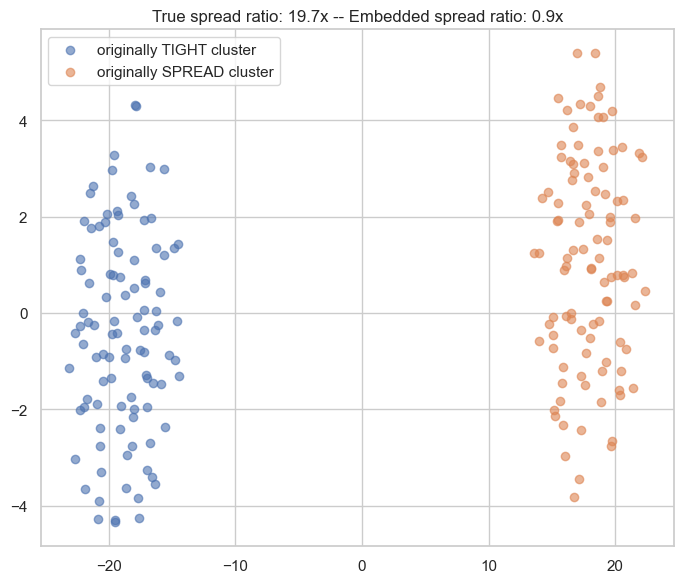

-> The embedded visual size ratio (0.9x) does not reliably reflect the true 19.7x spread ratio -- t-SNE has no obligation to preserve relative density or scale, only local neighbor rank order. Never read cluster size or inter-cluster distance off a t-SNE plot as if it were meaningful.


In [17]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(tsne_size_demo[size_labels == 0, 0], tsne_size_demo[size_labels == 0, 1], label="originally TIGHT cluster", alpha=0.6)
ax.scatter(tsne_size_demo[size_labels == 1, 0], tsne_size_demo[size_labels == 1, 1], label="originally SPREAD cluster", alpha=0.6)
ax.set_title(f"True spread ratio: {true_spread_ratio:.1f}x -- Embedded spread ratio: {embedded_ratio:.1f}x")
ax.legend()
plt.tight_layout()
plt.show()
print(f"-> The embedded visual size ratio ({embedded_ratio:.1f}x) does not reliably reflect the true {true_spread_ratio:.1f}x spread ratio -- t-SNE has no obligation to preserve relative density or scale, only local neighbor rank order. Never read cluster size or inter-cluster distance off a t-SNE plot as if it were meaningful.")


## 7. UMAP's `n_neighbors` and `min_dist`

UMAP's `n_neighbors` plays a role similar to perplexity (local vs. global structure balance); `min_dist` controls how tightly points are allowed to pack together in the embedding.


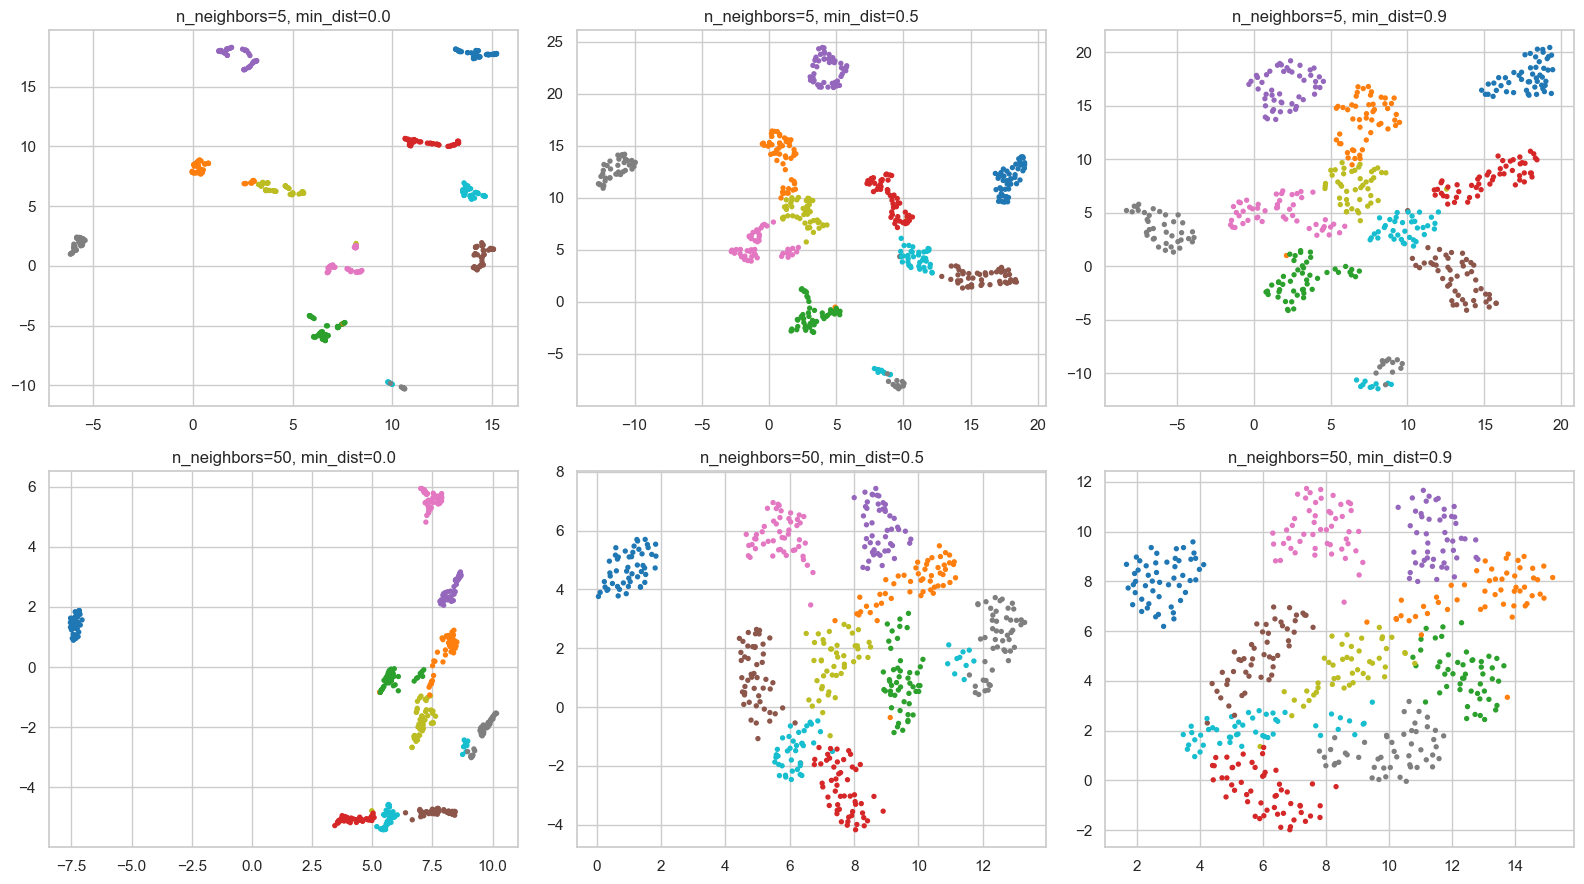

In [18]:
umap_param_results = []
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for i, n_neighbors in enumerate([5, 50]):
    for j, min_dist in enumerate([0.0, 0.5, 0.9]):
        embedding = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, random_state=42).fit_transform(X_digits[:500])
        trust = trustworthiness(X_digits[:500], embedding, n_neighbors=10)
        umap_param_results.append({"n_neighbors": n_neighbors, "min_dist": min_dist, "trustworthiness": round(trust, 4)})
        axes[i, j].scatter(embedding[:, 0], embedding[:, 1], c=y_digits_true[:500], cmap="tab10", s=8)
        axes[i, j].set_title(f"n_neighbors={n_neighbors}, min_dist={min_dist}")
plt.tight_layout()
plt.show()


In [19]:
pd.DataFrame(umap_param_results)


,n_neighbors,min_dist,trustworthiness
0,5,0.0,0.9866
1,5,0.5,0.9886
2,5,0.9,0.9893
3,50,0.0,0.9858
4,50,0.5,0.9852
5,50,0.9,0.9776


## 8. UMAP Can Transform New Data — t-SNE Cannot

t-SNE has no learned mapping function; it only ever produces a fixed embedding for the exact data it was fit on. UMAP learns an actual transform, so genuinely new points can be projected into an existing embedding.


In [20]:
X_digits_train, X_digits_new = X_digits[:1500], X_digits[1500:]
y_digits_train, y_digits_new = y_digits_true[:1500], y_digits_true[1500:]

umap_fitted = umap.UMAP(n_components=2, random_state=42).fit(X_digits_train)
embedding_train = umap_fitted.transform(X_digits_train)
embedding_new = umap_fitted.transform(X_digits_new)
print(f"UMAP fit on {len(X_digits_train)} training points, then transformed {len(X_digits_new)} genuinely new, never-seen points using the learned mapping.")


UMAP fit on 1500 training points, then transformed 297 genuinely new, never-seen points using the learned mapping.


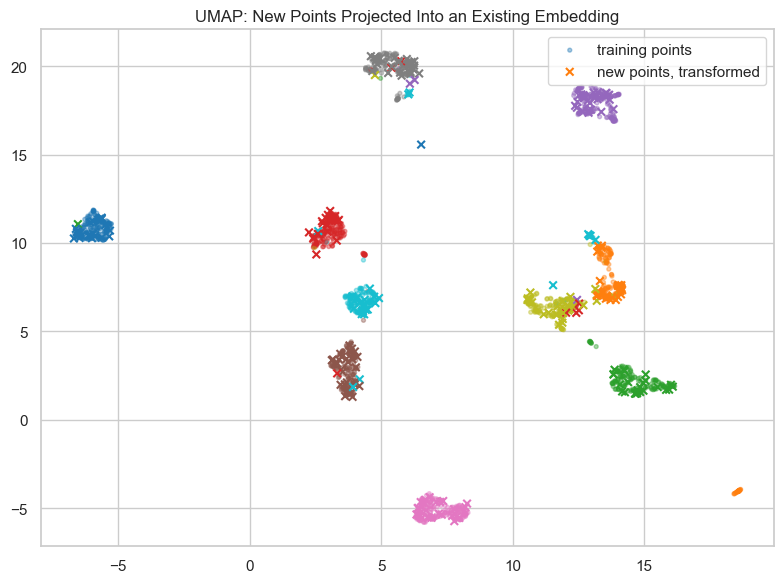

-> t-SNE's fit_transform has no separate .transform() step -- adding even one new point requires re-running the entire optimization from scratch on the combined dataset. UMAP's learned mapping avoids this entirely.


In [21]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(embedding_train[:, 0], embedding_train[:, 1], c=y_digits_train, cmap="tab10", s=8, alpha=0.4, label="training points")
ax.scatter(embedding_new[:, 0], embedding_new[:, 1], c=y_digits_new, cmap="tab10", s=30, marker="x", label="new points, transformed")
ax.set_title("UMAP: New Points Projected Into an Existing Embedding")
ax.legend()
plt.tight_layout()
plt.show()
print("-> t-SNE's fit_transform has no separate .transform() step -- adding even one new point requires re-running the entire optimization from scratch on the combined dataset. UMAP's learned mapping avoids this entirely.")


## 9. Speed Comparison — PCA vs. t-SNE vs. UMAP

Quantifying the computational cost gap directly rather than just asserting "t-SNE is slow."


In [22]:
timing_results = []
t0 = time.perf_counter(); PCA(n_components=2).fit_transform(X_digits); timing_results.append({"method": "PCA", "time_ms": round((time.perf_counter() - t0) * 1000, 1)})
t0 = time.perf_counter(); TSNE(n_components=2, random_state=42).fit_transform(X_digits); timing_results.append({"method": "t-SNE", "time_ms": round((time.perf_counter() - t0) * 1000, 1)})
t0 = time.perf_counter(); umap.UMAP(n_components=2, random_state=42).fit_transform(X_digits); timing_results.append({"method": "UMAP", "time_ms": round((time.perf_counter() - t0) * 1000, 1)})
print(f"Timed all 3 methods on {len(X_digits)} digits.")


Timed all 3 methods on 1797 digits.


In [23]:
timing_df = pd.DataFrame(timing_results).set_index("method")
timing_df


,time_ms
method,
PCA,1.8
t-SNE,1817.2
UMAP,3096.5


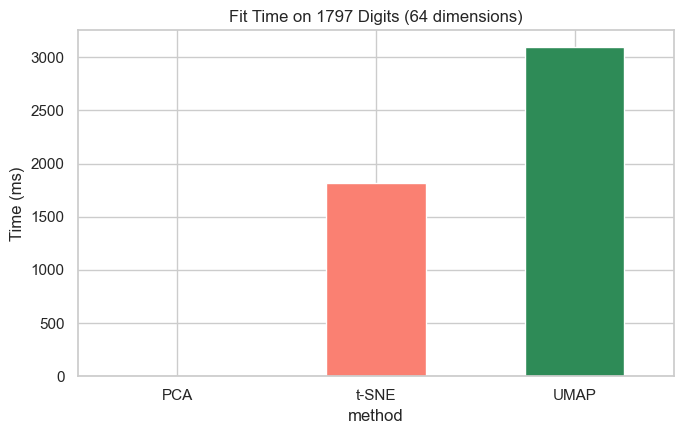

t-SNE is 1010x slower than PCA; UMAP is 1720x slower than PCA on this dataset size.


In [24]:
fig, ax = plt.subplots(figsize=(7, 4.5))
timing_df["time_ms"].plot(kind="bar", ax=ax, color=["steelblue", "salmon", "seagreen"])
ax.set_ylabel("Time (ms)"); ax.set_title(f"Fit Time on {len(X_digits)} Digits (64 dimensions)")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()
print(f"t-SNE is {timing_df.loc['t-SNE', 'time_ms'] / timing_df.loc['PCA', 'time_ms']:.0f}x slower than PCA; UMAP is {timing_df.loc['UMAP', 'time_ms'] / timing_df.loc['PCA', 'time_ms']:.0f}x slower than PCA on this dataset size.")


## 10. Full Comparison on Digits — PCA vs. t-SNE vs. UMAP

Every method side by side on the same real, genuinely high-dimensional dataset.


In [25]:
pca_digits = PCA(n_components=2).fit_transform(X_digits)
tsne_digits = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_digits)
umap_digits = umap.UMAP(n_components=2, random_state=42).fit_transform(X_digits)
print(f"Fitted all 3 methods on the full {len(X_digits)}-point, 64-dimensional Digits dataset.")


Fitted all 3 methods on the full 1797-point, 64-dimensional Digits dataset.


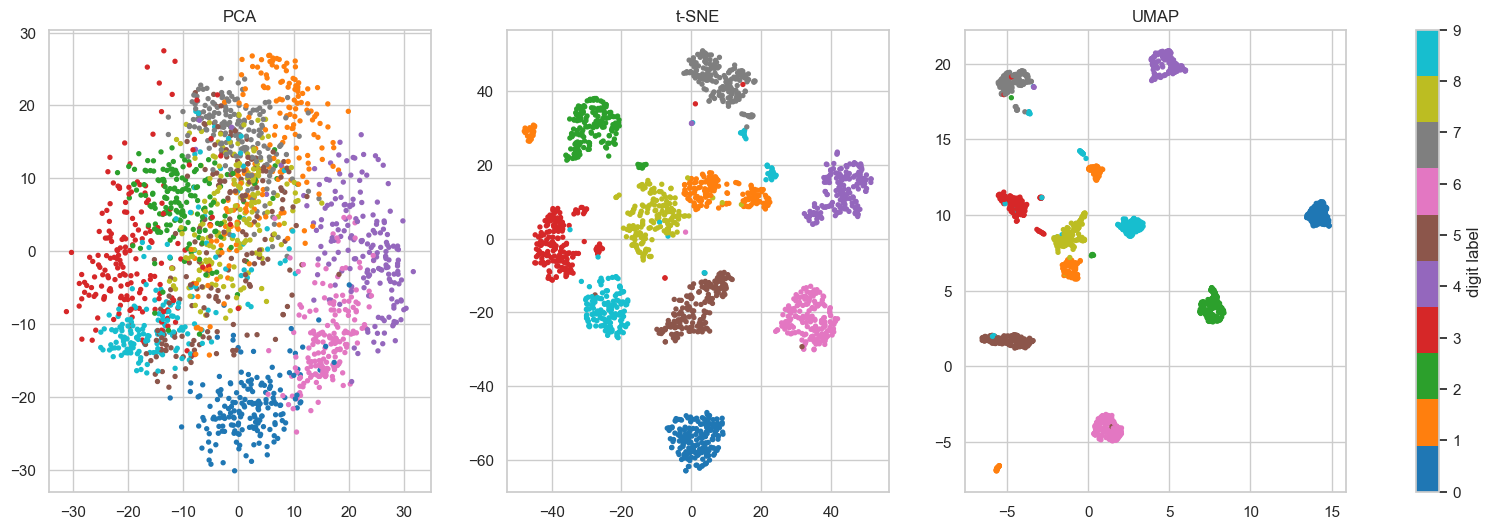

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, embedding, title in zip(axes, [pca_digits, tsne_digits, umap_digits], ["PCA", "t-SNE", "UMAP"]):
    scatter = ax.scatter(embedding[:, 0], embedding[:, 1], c=y_digits_true, cmap="tab10", s=8)
    ax.set_title(title)
plt.colorbar(scatter, ax=axes, label="digit label", fraction=0.02)
plt.show()


In [27]:
comparison_results = []
for name, embedding in [("PCA", pca_digits), ("t-SNE", tsne_digits), ("UMAP", umap_digits)]:
    trust = trustworthiness(X_digits, embedding, n_neighbors=10)
    comparison_results.append({"method": name, "trustworthiness": round(trust, 4)})

comparison_df = pd.DataFrame(comparison_results).set_index("method")
comparison_df


,trustworthiness
method,
PCA,0.8300
t-SNE,0.9927
UMAP,0.9875


In [28]:
robustness_check = []
for k in [5, 10, 20, 50]:
    row = {"n_neighbors_for_metric": k}
    for name, embedding in [("PCA", pca_digits), ("t-SNE", tsne_digits), ("UMAP", umap_digits)]:
        row[name] = round(trustworthiness(X_digits, embedding, n_neighbors=k), 4)
    robustness_check.append(row)

pd.DataFrame(robustness_check).set_index("n_neighbors_for_metric")


,PCA,t-SNE,UMAP
n_neighbors_for_metric,,,
5,0.8304,0.9951,0.9884
10,0.8300,0.9927,0.9875
20,0.8290,0.9887,0.9855
50,0.8330,0.9792,0.9763


In [29]:
print("-> The ranking (t-SNE/UMAP clearly ahead of PCA) stays consistent across every n_neighbors value used to COMPUTE the trustworthiness metric itself -- confirming Section 10's conclusion isn't an artifact of one arbitrary metric setting.")


-> The ranking (t-SNE/UMAP clearly ahead of PCA) stays consistent across every n_neighbors value used to COMPUTE the trustworthiness metric itself -- confirming Section 10's conclusion isn't an artifact of one arbitrary metric setting.


In [30]:
best_method = comparison_df["trustworthiness"].idxmax()
print(f"Highest local-structure preservation on Digits: {best_method} ({comparison_df.loc[best_method, 'trustworthiness']:.4f})")
print(f"PCA (for reference, linear baseline): {comparison_df.loc['PCA', 'trustworthiness']:.4f}")
print("-> Visually, t-SNE and UMAP both separate the 10 digit classes into far cleaner, more distinct groups than PCA's 2D projection -- exactly the payoff of non-linear structure preservation on genuinely high-dimensional data, at the real cost (Section 9) of speed and (Section 5-6) of losing PCA's determinism and global-distance meaning.")


Highest local-structure preservation on Digits: t-SNE (0.9927)
PCA (for reference, linear baseline): 0.8300
-> Visually, t-SNE and UMAP both separate the 10 digit classes into far cleaner, more distinct groups than PCA's 2D projection -- exactly the payoff of non-linear structure preservation on genuinely high-dimensional data, at the real cost (Section 9) of speed and (Section 5-6) of losing PCA's determinism and global-distance meaning.


## 11. Summary

t-SNE and UMAP directly solved the specific problem the PCA topic ended on -- both preserved the Swiss roll's local structure far better than PCA's linear projection could (Section 2) -- but this notebook was equally deliberate about what they give up in exchange: no deterministic output (Section 5), no reliable meaning in cluster size or inter-cluster distance (Section 6, the single most important pitfall to internalize), and for t-SNE specifically, no ability to project new data into an existing embedding (Section 8, where UMAP's learned mapping is the genuine advantage). These are visualization and local-structure-preservation tools, not general-purpose dimensionality reduction replacements for PCA -- the right tool depends on whether the downstream need is "explore what's here" (t-SNE/UMAP) or "reduce dimensions for a model, with global structure and new-data support intact" (PCA).

See [README.md](README.md) for the full mathematical derivations and a pitfalls reference.
